# MobileNetV2 – Classificação CPRE (v7)

**Diagnóstico persistente:** A fase 1 (backbone congelado) nunca aprende — val_F1 ≤ 0.30 em todas as versões. Isto faz com que a fase 2 comece sempre de um mau ponto de partida.

**Solução v7 — Differential Learning Rates:**
- **Sem fase de backbone congelado** — treino único do início ao fim
- **LR diferenciado por grupo de camadas:**
  - Camadas iniciais (features 0-9): LR muito baixo (1e-5) — preserva features genéricas
  - Camadas finais (features 10-18): LR médio (5e-5) — adapta ao domínio médico  
  - Classificador: LR alto (1e-3) — aprende rápido
- **Warm-up** nas primeiras 5 épocas para estabilizar
- Base do **v4** (CLAHE offline) + **v6** (RGB + ImageNet norm)

In [61]:
!pip install -q torchmetrics opencv-python-headless tqdm

In [62]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    raise RuntimeError('GPU não encontrada! Ativa em Settings > Accelerator > GPU T4 x2')

Dispositivo: cuda
GPU: Tesla T4


In [63]:
import os, cv2
from tqdm import tqdm

INPUT_DIR  = '/kaggle/input/datasets/filipapereira30/dataset-2/MIQR-CC-Dataset/training/dataset'
OUTPUT_DIR = '/kaggle/working/dataset_clahe'

if os.path.exists(OUTPUT_DIR) and any(os.scandir(OUTPUT_DIR)):
    print(f'dataset_clahe já existe — a saltar.')
else:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    for split in ['train', 'val', 'test']:
        for cls in os.listdir(os.path.join(INPUT_DIR, split)):
            in_dir  = os.path.join(INPUT_DIR,  split, cls)
            out_dir = os.path.join(OUTPUT_DIR, split, cls)
            os.makedirs(out_dir, exist_ok=True)
            print(f'Processing {split}/{cls}...')
            for fname in tqdm(os.listdir(in_dir)):
                img = cv2.imread(os.path.join(in_dir, fname), cv2.IMREAD_GRAYSCALE)
                if img is None: continue
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
                cv2.imwrite(os.path.join(out_dir, fname), clahe.apply(img))
    print('CLAHE preprocessing completed.')

base_dir = OUTPUT_DIR
print(f'base_dir = {base_dir}')

dataset_clahe já existe — a saltar.
base_dir = /kaggle/working/dataset_clahe


In [64]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random, time, warnings
warnings.filterwarnings('ignore')

from PIL import Image
from pathlib import Path
from datetime import datetime

from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, f1_score,
                              roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchmetrics.classification import MulticlassF1Score

print('Imports OK')

Imports OK


In [65]:
model_path = '/kaggle/working/MIA_AP_my_models'
os.makedirs(model_path, exist_ok=True)

def get_versioned_model_name(base_path):
    base = Path(base_path)
    ts   = datetime.now().strftime('%Y%m%d_%H%M%S')
    return str(base.parent / f'{base.stem}_{ts}{base.suffix}')

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 60
PATIENCE   = 15
SEED       = 42
CW_POWER   = 0.5
WARMUP_EP  = 5    # épocas de warm-up

# LRs diferenciados por grupo
LR_EARLY   = 1e-5   # camadas iniciais (features 0-9)
LR_LATE    = 5e-5   # camadas finais (features 10-18)
LR_HEAD    = 1e-3   # classificador

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f'Config OK | LR_EARLY={LR_EARLY} | LR_LATE={LR_LATE} | LR_HEAD={LR_HEAD}')

Config OK | LR_EARLY=1e-05 | LR_LATE=5e-05 | LR_HEAD=0.001


In [66]:
phases = ['train', 'val', 'test']
data   = {phase: {'images': [], 'labels': []} for phase in phases}

class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])
num_class = len(class_names)
print(f'Classes ({num_class}): {class_names}')

valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
for phase in phases:
    for i, cname in enumerate(class_names):
        cdir = os.path.join(base_dir, phase, cname)
        imgs = [os.path.join(cdir, f) for f in os.listdir(cdir) if f.lower().endswith(valid_exts)]
        data[phase]['images'].extend(imgs)
        data[phase]['labels'].extend([i] * len(imgs))

for phase in phases:
    labels = data[phase]['labels']
    print(f'\n{phase.upper()} – {len(labels)} imagens')
    for i, c in enumerate(class_names):
        n = labels.count(i)
        print(f'  {c}: {n} ({100*n/len(labels):.1f}%)')

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']

TRAIN – 1067 imagens
  Biliary_Leaks: 110 (10.3%)
  Lithiasis: 505 (47.3%)
  Normal: 197 (18.5%)
  Stricture: 255 (23.9%)

VAL – 234 imagens
  Biliary_Leaks: 24 (10.3%)
  Lithiasis: 98 (41.9%)
  Normal: 59 (25.2%)
  Stricture: 53 (22.6%)

TEST – 267 imagens
  Biliary_Leaks: 17 (6.4%)
  Lithiasis: 123 (46.1%)
  Normal: 43 (16.1%)
  Stricture: 84 (31.5%)


In [67]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.RandomVerticalFlip(p=0.4),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ColorJitter(contrast=0.3, brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('Transforms: RGB + ImageNet normalization')

Transforms: RGB + ImageNet normalization


In [68]:
class ERCPDataset(Dataset):
    def __init__(self, image_files, labels, transform):
        self.image_files = image_files
        self.labels      = labels
        self.transform   = transform
    def __len__(self): return len(self.image_files)
    def __getitem__(self, idx):
        img = Image.open(self.image_files[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]

train_labels_np = np.array(data['train']['labels'])
cw_raw    = compute_class_weight('balanced', classes=np.arange(num_class), y=train_labels_np)
cw_smooth = cw_raw ** CW_POWER
cw_smooth = cw_smooth / cw_smooth.mean()
cw_tensor = torch.tensor(cw_smooth, dtype=torch.float32).to(device)

print('Class weights (suavizados):')
for i, (r, s) in enumerate(zip(cw_raw, cw_smooth)):
    print(f'  {class_names[i]}: {r:.3f} → {s:.3f}')

train_ds = ERCPDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds   = ERCPDataset(data['val']['images'],   data['val']['labels'],   val_transforms)
test_ds  = ERCPDataset(data['test']['images'],  data['test']['labels'],  val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'\nTrain: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Class weights (suavizados):
  Biliary_Leaks: 2.425 → 1.393
  Lithiasis: 0.528 → 0.650
  Normal: 1.354 → 1.041
  Stricture: 1.046 → 0.915

Train: 1067 | Val: 234 | Test: 267


## Modelo com Differential Learning Rates

3 grupos de parâmetros com LRs distintos:
- **Camadas iniciais** (features 0-9): LR=1e-5 — preservam features genéricas do ImageNet
- **Camadas finais** (features 10-18): LR=5e-5 — adaptam-se ao domínio médico
- **Classificador**: LR=1e-3 — aprende as classes específicas rapidamente

In [69]:
set_seed(SEED)
model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.3),
    nn.Linear(256, num_class)
)
model = model.to(device)

# Dividir em 3 grupos de parâmetros
early_layers = list(model.features[:10].parameters())   # primeiras 10 camadas
late_layers  = list(model.features[10:].parameters())   # últimas camadas
head_params  = list(model.classifier.parameters())      # classificador

optimizer = torch.optim.AdamW([
    {'params': early_layers, 'lr': LR_EARLY},
    {'params': late_layers,  'lr': LR_LATE},
    {'params': head_params,  'lr': LR_HEAD}
], weight_decay=1e-4)

print(f'Parâmetros totais: {sum(p.numel() for p in model.parameters()):,}')
print(f'  early (LR={LR_EARLY}): {sum(p.numel() for p in early_layers):,}')
print(f'  late  (LR={LR_LATE}): {sum(p.numel() for p in late_layers):,}')
print(f'  head  (LR={LR_HEAD}): {sum(p.numel() for p in head_params):,}')

Parâmetros totais: 2,552,836
  early (LR=1e-05): 185,088
  late  (LR=5e-05): 2,038,784
  head  (LR=0.001): 328,964


In [70]:
def mixup_data(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1-lam) * criterion(pred, y_b)

loss_fn = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.1)

# Scheduler com warm-up: começa com LR baixo e sobe gradualmente
def lr_lambda(epoch):
    if epoch < WARMUP_EP:
        return (epoch + 1) / WARMUP_EP
    return 1.0

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
main_scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - WARMUP_EP, eta_min=1e-7
)

model_name = get_versioned_model_name(f'{model_path}/mobilenet_v2_v7.pth')
print(f'Loss: CrossEntropyLoss (class weights suavizados + label_smoothing=0.1)')
print(f'Warm-up: {WARMUP_EP} épocas | Cosine annealing: {EPOCHS-WARMUP_EP} épocas')

Loss: CrossEntropyLoss (class weights suavizados + label_smoothing=0.1)
Warm-up: 5 épocas | Cosine annealing: 55 épocas



 Treino com Differential LRs | epochs=60 | warm-up=5
Ep   1/60  loss=1.3984  val_loss=1.3661  F1=0.2372  val_F1=0.1476  LR_head=4.00e-04  mixup=False
  ✔ Melhor modelo guardado (val F1=0.1476)
Ep   2/60  loss=1.3763  val_loss=1.3700  F1=0.1758  val_F1=0.1480  LR_head=6.00e-04  mixup=False
  ✔ Melhor modelo guardado (val F1=0.1480)
Ep   3/60  loss=1.3620  val_loss=1.3864  F1=0.2386  val_F1=0.2235  LR_head=8.00e-04  mixup=False
  ✔ Melhor modelo guardado (val F1=0.2235)
Ep   4/60  loss=1.3294  val_loss=1.3677  F1=0.3284  val_F1=0.2501  LR_head=1.00e-03  mixup=False
  ✔ Melhor modelo guardado (val F1=0.2501)
Ep   5/60  loss=1.2848  val_loss=1.4218  F1=0.4440  val_F1=0.2246  LR_head=1.00e-03  mixup=False
Ep   6/60  loss=1.2687  val_loss=1.3590  F1=0.2991  val_F1=0.2942  LR_head=9.99e-04  mixup=True
  ✔ Melhor modelo guardado (val F1=0.2942)
Ep   7/60  loss=1.2928  val_loss=1.3381  F1=0.3803  val_F1=0.3776  LR_head=9.97e-04  mixup=True
  ✔ Melhor modelo guardado (val F1=0.3776)
Ep   8/60  

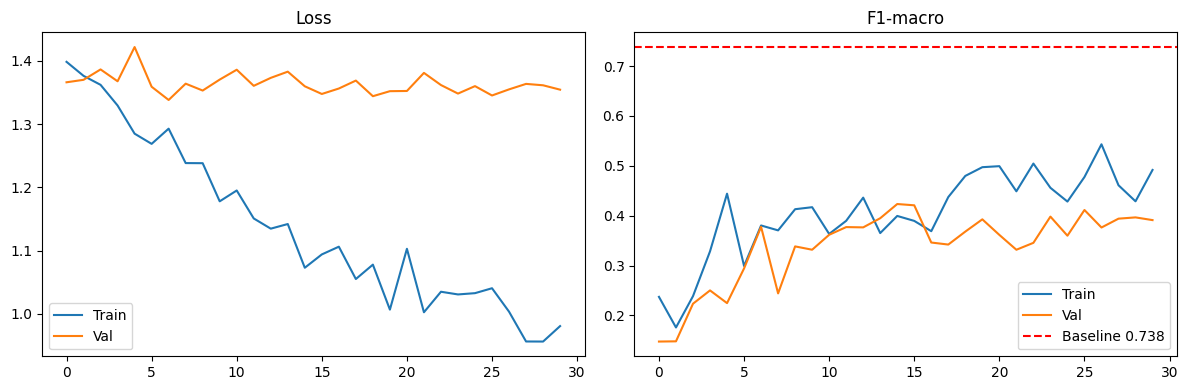

In [71]:
f1_metric = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
best_f1, best_epoch, no_improve = -1.0, -1, 0
history = {'loss': [], 'val_loss': [], 'f1': [], 'val_f1': []}

print(f'\n{"="*60}')
print(f' Treino com Differential LRs | epochs={EPOCHS} | warm-up={WARMUP_EP}')
print(f'{"="*60}')

t0 = time.perf_counter()

for epoch in range(EPOCHS):
    use_mixup = epoch >= WARMUP_EP  # Mixup só após warm-up

    # ── TREINO ───────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    y_pred_all = torch.tensor([], dtype=torch.float32, device=device)
    y_all      = torch.tensor([], dtype=torch.long,    device=device)

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        if use_mixup:
            inputs, y_a, y_b, lam = mixup_data(inputs, labels)
            outputs = model(inputs)
            loss    = mixup_criterion(loss_fn, outputs, y_a, y_b, lam)
        else:
            outputs = model(inputs)
            loss    = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.detach() * inputs.size(0)
        y_pred_all = torch.cat([y_pred_all, outputs.detach()], dim=0)
        y_all      = torch.cat([y_all, labels], dim=0)

    epoch_loss = (running_loss / len(train_loader.dataset)).item()
    train_f1   = f1_metric(y_pred_all.argmax(dim=1), y_all).item()

    # ── VALIDAÇÃO ────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    y_pred_v = torch.tensor([], dtype=torch.float32, device=device)
    y_v      = torch.tensor([], dtype=torch.long,    device=device)

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs  = model(inputs)
            val_loss += loss_fn(outputs, labels).detach() * inputs.size(0)
            y_pred_v  = torch.cat([y_pred_v, outputs], dim=0)
            y_v       = torch.cat([y_v, labels],       dim=0)

    val_epoch_loss = (val_loss / len(val_loader.dataset)).item()
    val_f1         = f1_metric(y_pred_v.argmax(dim=1), y_v).item()

    history['loss'].append(epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    # Scheduler: warm-up nas primeiras épocas, cosine depois
    if epoch < WARMUP_EP:
        warmup_scheduler.step()
    else:
        main_scheduler.step()

    lr_head = optimizer.param_groups[2]['lr']
    print(f'Ep {epoch+1:3d}/{EPOCHS}  loss={epoch_loss:.4f}  '
          f'val_loss={val_epoch_loss:.4f}  F1={train_f1:.4f}  '
          f'val_F1={val_f1:.4f}  LR_head={lr_head:.2e}  mixup={use_mixup}')

    if val_f1 > best_f1:
        best_f1, best_epoch = val_f1, epoch+1
        torch.save(model.state_dict(), model_name)
        print(f'  ✔ Melhor modelo guardado (val F1={best_f1:.4f})')
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= PATIENCE:
        print(f'Early stopping ep {epoch+1}. Melhor: {best_epoch}, F1={best_f1:.4f}')
        break

print(f'\nTreino concluído em {time.perf_counter()-t0:.1f}s | Melhor val F1: {best_f1:.4f}')

# Curvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['loss'], label='Train'); ax1.plot(history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(history['f1'], label='Train'); ax2.plot(history['val_f1'], label='Val')
ax2.axhline(0.738, color='red', linestyle='--', label='Baseline 0.738')
ax2.set_title('F1-macro'); ax2.legend()
plt.tight_layout()
plt.savefig(f'{model_path}/curves_v7.png', dpi=150)
plt.show()

In [72]:
model.load_state_dict(torch.load(model_name))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(device))
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(np.argmax(probs, axis=1))
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

f1  = f1_score(all_labels, all_preds, average='macro')
acc = accuracy_score(all_labels, all_preds)

print(f'\n{"="*55}')
print(f' Accuracy  : {acc:.4f}')
print(f' F1-macro  : {f1:.4f}')
print(f' Baseline  : 0.7380')
print(f' Delta     : {f1-0.738:+.4f}')
print(f'{"="*55}\n')
print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=4, zero_division=0))


 Accuracy  : 0.5431
 F1-macro  : 0.4574
 Baseline  : 0.7380
 Delta     : -0.2806

               precision    recall  f1-score   support

Biliary_Leaks     0.4211    0.4706    0.4444        17
    Lithiasis     0.5401    0.8211    0.6516       123
       Normal     0.5000    0.2326    0.3175        43
    Stricture     0.6341    0.3095    0.4160        84

     accuracy                         0.5431       267
    macro avg     0.5238    0.4585    0.4574       267
 weighted avg     0.5557    0.5431    0.5105       267



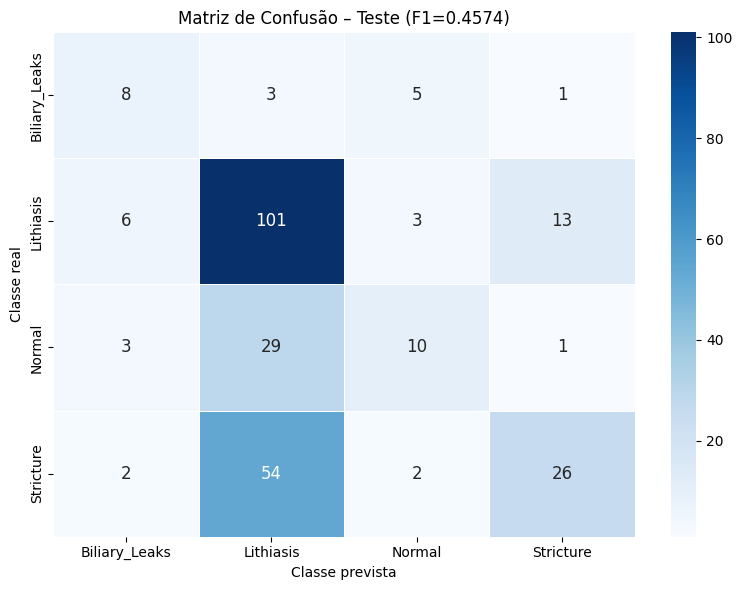

In [73]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 12})
plt.ylabel('Classe real'); plt.xlabel('Classe prevista')
plt.title(f'Matriz de Confusão – Teste (F1={f1:.4f})')
plt.tight_layout()
plt.savefig(f'{model_path}/confusion_matrix.png', dpi=200)
plt.show()

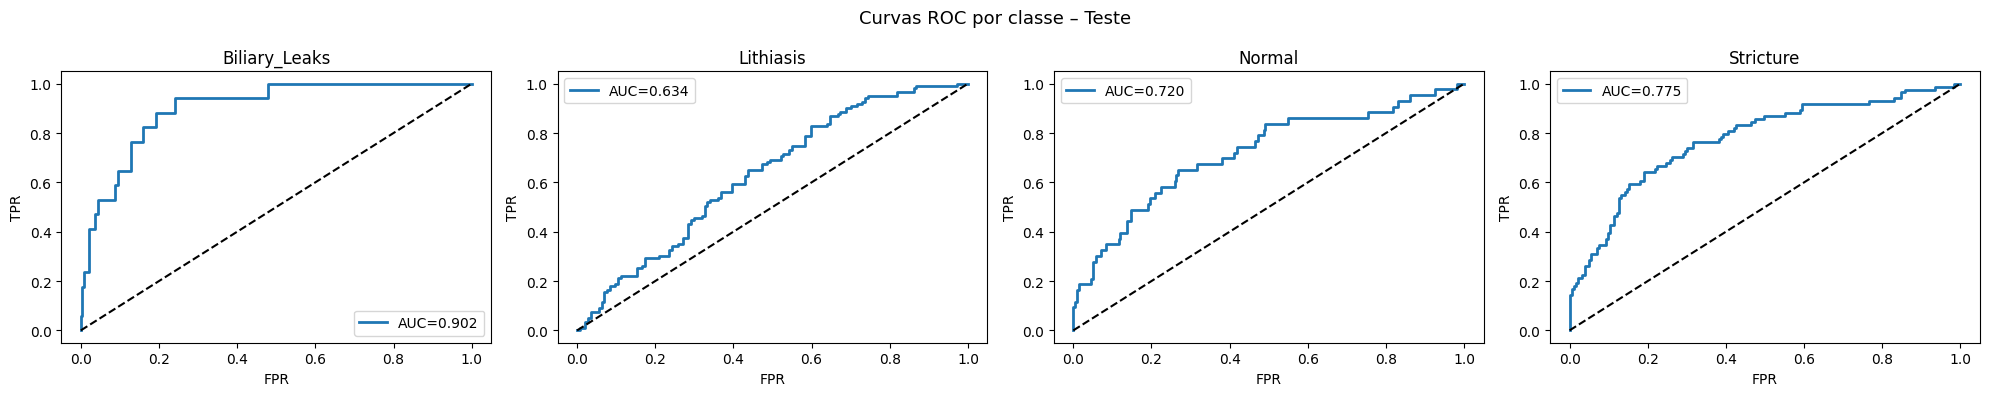

AUC-ROC macro (OvR): 0.7578


In [74]:
y_bin = label_binarize(all_labels, classes=np.arange(num_class))
fig, axes = plt.subplots(1, num_class, figsize=(5*num_class, 4))
for i, (ax, cname) in enumerate(zip(axes, class_names)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_val = roc_auc_score(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=2, label=f'AUC={auc_val:.3f}')
    ax.plot([0,1],[0,1],'k--'); ax.set_title(cname)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend()
plt.suptitle('Curvas ROC por classe – Teste', fontsize=13)
plt.tight_layout()
plt.savefig(f'{model_path}/roc_curves.png', dpi=150)
plt.show()
mean_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
print(f'AUC-ROC macro (OvR): {mean_auc:.4f}')

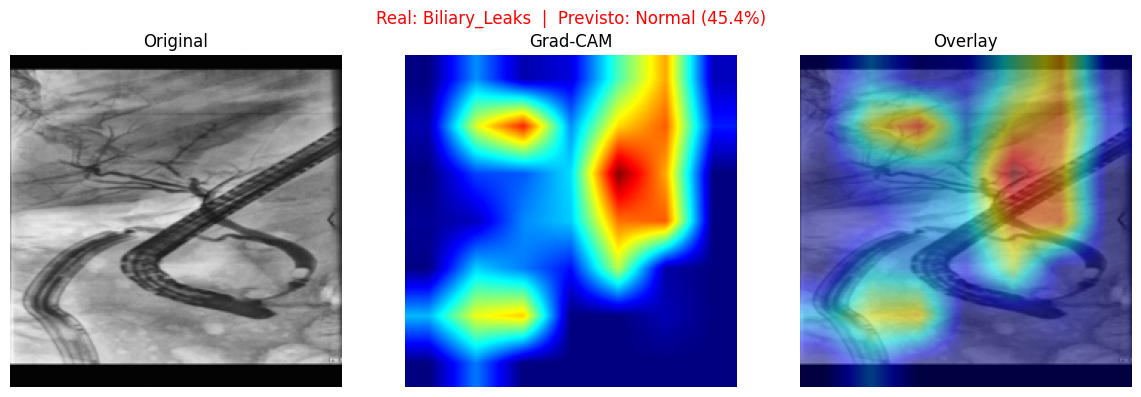

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_0.png


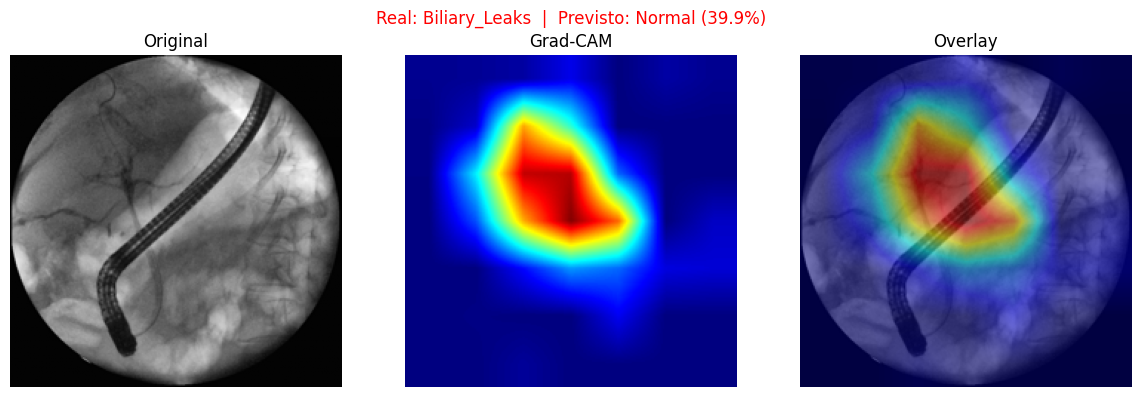

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_1.png


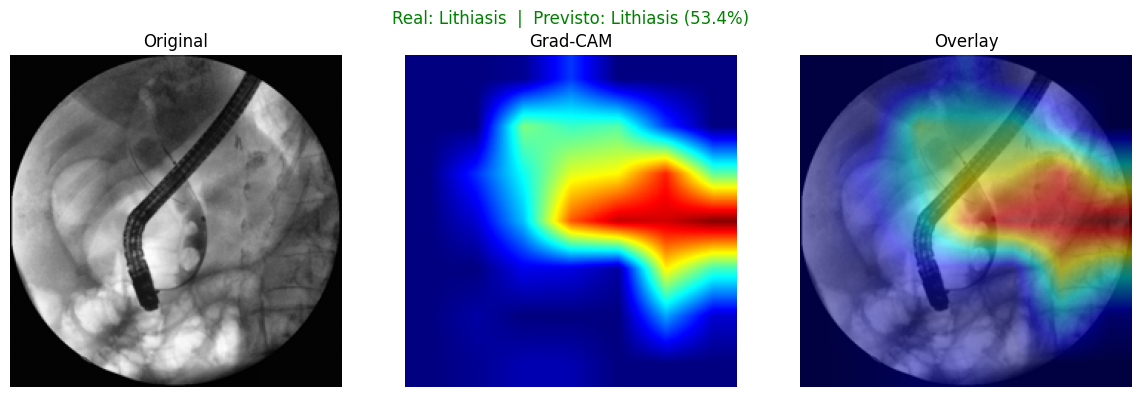

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_0.png


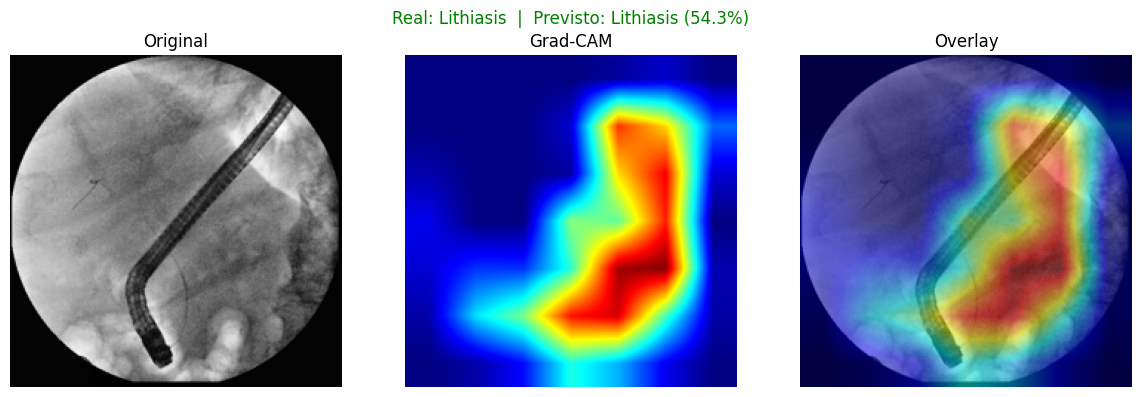

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_1.png


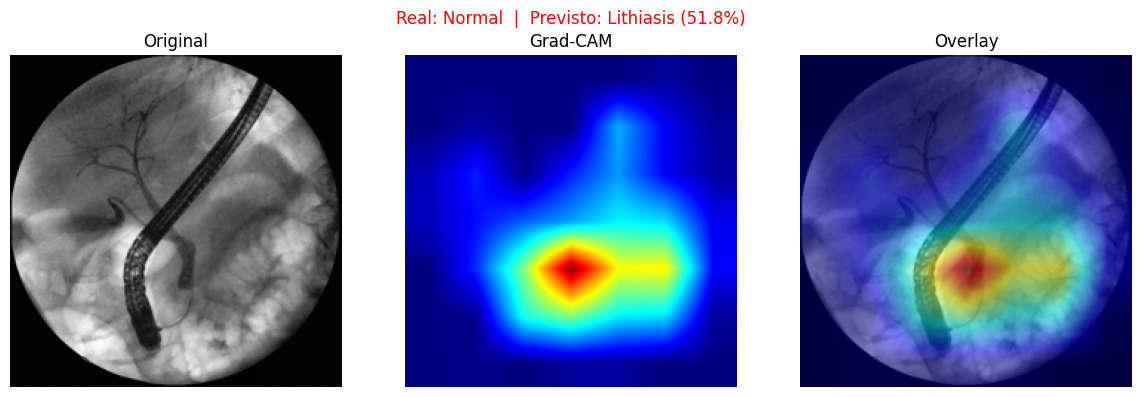

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_0.png


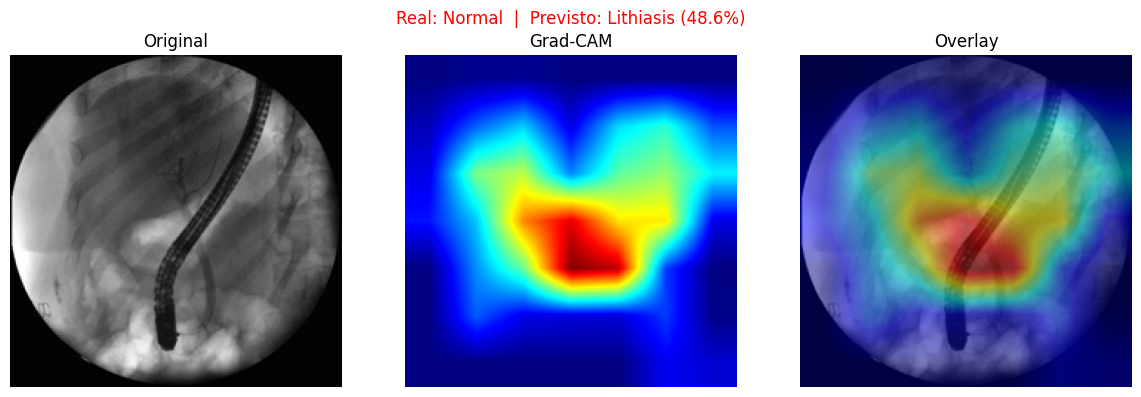

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_1.png


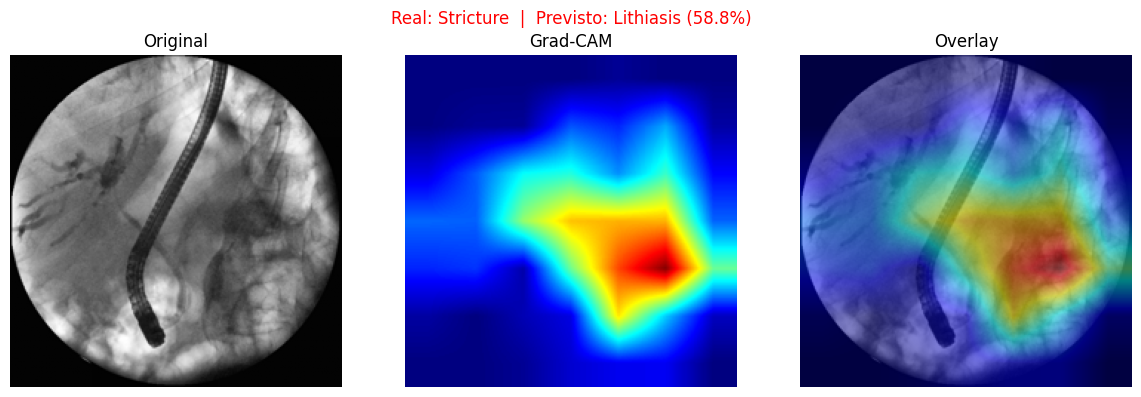

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_0.png


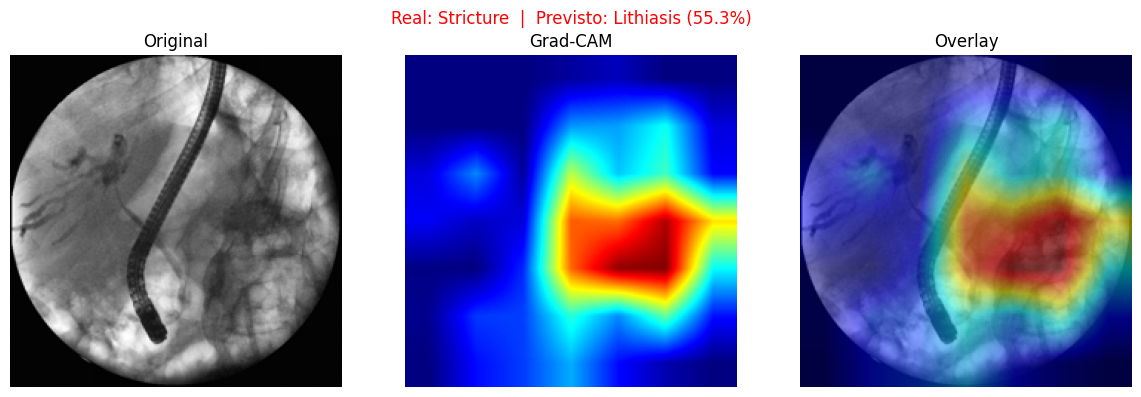

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_1.png


In [75]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        x   = input_tensor.unsqueeze(0).to(device).requires_grad_(True)
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        self.model.zero_grad()
        oh = torch.zeros_like(out); oh[0, class_idx] = 1.0
        out.backward(gradient=oh)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx, F.softmax(out, dim=1)[0, class_idx].item()

gradcam = GradCAM(model, target_layer=model.features[-1])

def show_gradcam(img_path, true_label, save_path=None):
    img_pil    = Image.open(img_path).convert('RGB')
    img_tensor = val_transforms(img_pil)
    cam, pred_idx, prob = gradcam.generate(img_tensor)
    raw     = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)).convert('L'))
    raw_rgb = cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)
    cam_r   = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap((cam_r*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5*raw_rgb + 0.5*heatmap).astype(np.uint8)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw, cmap='gray'); axes[0].set_title('Original');  axes[0].axis('off')
    axes[1].imshow(heatmap);          axes[1].set_title('Grad-CAM');  axes[1].axis('off')
    axes[2].imshow(overlay);          axes[2].set_title('Overlay');   axes[2].axis('off')
    cor = 'green' if pred_idx == true_label else 'red'
    plt.suptitle(f'Real: {class_names[true_label]}  |  Previsto: {class_names[pred_idx]} ({prob:.1%})',
                 fontsize=12, color=cor)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=200)
    plt.show()

os.makedirs(f'{model_path}/gradcam', exist_ok=True)
for ci, cname in enumerate(class_names):
    imgs = [(p,l) for p,l in zip(data['test']['images'], data['test']['labels']) if l == ci]
    for k, (path, lbl) in enumerate(imgs[:2]):
        save_file = f'{model_path}/gradcam/gradcam_{cname}_{k}.png'
        show_gradcam(path, lbl, save_path=save_file)
        print(f'Guardado: {save_file}')

In [76]:
print('='*60)
print('RESUMO COMPARATIVO')
print('='*60)
print(f'  v0 (professor, CPU)      test F1 = 0.4564')
print(f'  v1 (CPU)                 test F1 = 0.4973')
print(f'  v2 (GPU, colapso)        test F1 = 0.3063')
print(f'  v3 (GPU)                 test F1 = 0.4771')
print(f'  v4 (CLAHE offline)       test F1 = 0.5558  ← melhor até agora')
print(f'  v5 (FocalLoss+gradual)   test F1 = 0.4112')
print(f'  v6 (RGB+ImageNet)        test F1 = 0.5215')
print(f'  v7 (Differential LR)    test F1 = {f1:.4f}')
print(f'  Baseline artigo                  = 0.7380')
print(f'  Delta vs baseline                = {f1-0.738:+.4f}')
print('='*60)

RESUMO COMPARATIVO
  v0 (professor, CPU)      test F1 = 0.4564
  v1 (CPU)                 test F1 = 0.4973
  v2 (GPU, colapso)        test F1 = 0.3063
  v3 (GPU)                 test F1 = 0.4771
  v4 (CLAHE offline)       test F1 = 0.5558  ← melhor até agora
  v5 (FocalLoss+gradual)   test F1 = 0.4112
  v6 (RGB+ImageNet)        test F1 = 0.5215
  v7 (Differential LR)    test F1 = 0.4574
  Baseline artigo                  = 0.7380
  Delta vs baseline                = -0.2806
